# Overview

## Create the simulations

In [1]:
import numpy as np
from lucifex.io import write
from lucifex.sim import run, xdmf_to_npz, Simulation
from lucifex.plt import (
    plot_colormap, plot_line, create_multifigure, save_figure,
    get_ipynb_file_name, set_ipynb_variable, plot_colormap_multifigure,
)
from lucifex.utils.npy_utils import as_index
from crocodil.theory.system_a import threshold_rayleigh
from crocodil.dns.system_b import dns_system_b, thermal_rayleigh, SYSTEM_B_REFERENCE

STORE = 1
WRITE = None
DIR_ROOT = f'./figures/{get_ipynb_file_name()}'
NX = set_ipynb_variable('NX', 80)
NY = set_ipynb_variable('NY', 80)
ANIM = set_ipynb_variable('ANIM', False)

theta_buoy_opts = (True, False)
simulations: dict[bool, Simulation] = {}

for theta_buoy in theta_buoy_opts:
    simulations[theta_buoy] = dns_system_b(
        store_delta=STORE, 
        write_delta=WRITE, 
        dir_root=DIR_ROOT, 
        dir_uid=True,
    )(
        Nx=NX,
        Ny=NY,
        cell='quadrilateral',
        scaling='advective',
        **SYSTEM_B_REFERENCE.replace(gamma=0.5),
        theta_buoy=theta_buoy,
        dt_max=0.1,
        dt_Cu=0.75,
        dt_Cd=0.75,
        dt_Cr=0.1,
        c_stabilization=None,
        theta_stabilization=None,
        c_limits=True,
        theta_limits=True,
        diagnostic=True,
    )
    
Ra, Le, gamma, Lx, Ly = (
    float(i) for i in simulations[True]['Ra', 'Le', 'gamma', 'Lx', 'Ly']
)
Ra_thermal = thermal_rayleigh(Ra, Le, gamma)
Ra_thresh = threshold_rayleigh(Lx, Ly, NX, 2)
print(f"Ra_solutal = {Ra} , Ra_thermal = {Ra_thermal} , Ra_thresh = {Ra_thresh}")

Ra_solutal = 1000.0 , Ra_thermal = 500.0 , Ra_thresh = 1800.0


## Run the simulations

In [2]:
n_stop = set_ipynb_variable('N_STOP', 200)
t_stop = 100.0
dt_init = 1e-6
n_init = 10

for theta_buoy, sim in simulations.items():
    run(sim, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, show_progress=True)
    if WRITE: 
        xdmf_to_npz(sim, delete_xdmf=False)
    else:
        write(sim.parameters, sim.parameter_file, sim.dir_path, mode='w')

theta_title = lambda buoy: f"$\\theta_0^+={'0' if buoy else '1'}$"

Environment variable `N_STOP=200`


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

## Physical diagnostics

### Solutal and thermal flux

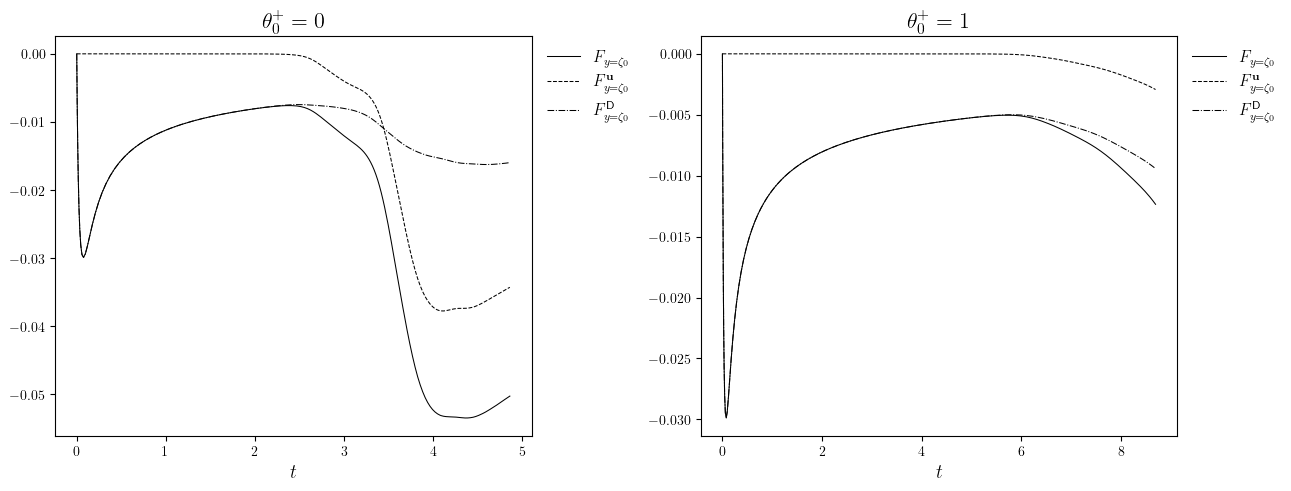

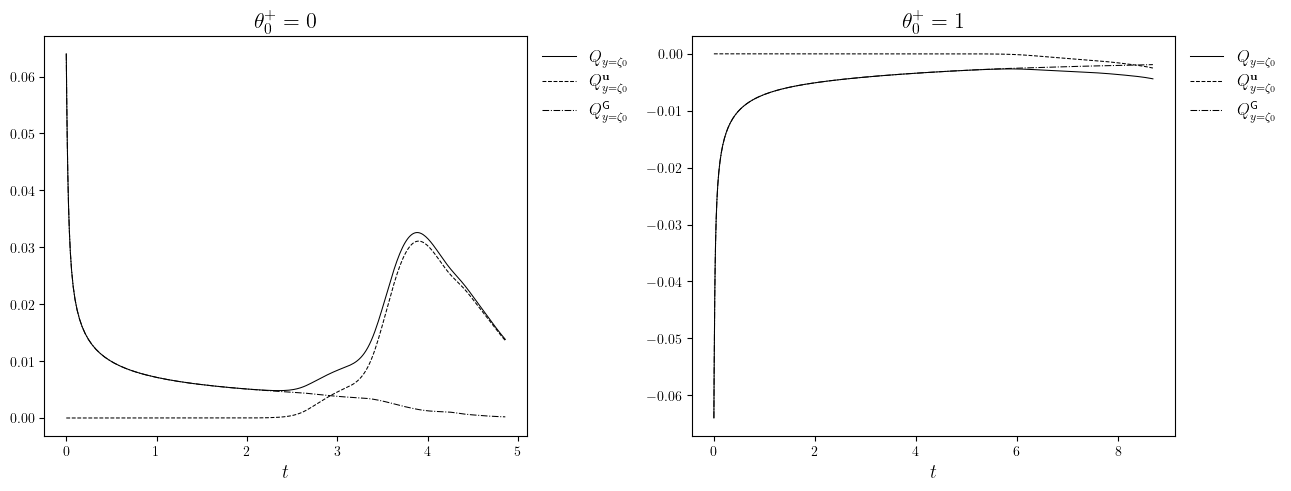

In [3]:
mfig_f, axs_f, _ = create_multifigure(n_cols=2)
mfig_q, axs_q, _ = create_multifigure(n_cols=2)

for i, (theta_buoy, sim) in enumerate(simulations.items()):
    f, q = sim['f', 'q']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    qZeta0, qZetaPlus, qZetaMinus = q.split()
    plot_line(
        mfig_f, axs_f[i],
        [
            (fZeta0.time_series, [np.sum(i) for i in fZeta0.value_series]), 
            (fZeta0.time_series, fZeta0.value_series)
        ],
        cyc='black',
        x_label='$t$',
        title=theta_title(theta_buoy),
        legend_labels=[
            '$F_{y=\zeta_0}$', 
            '$F_{y=\zeta_0}^{\mathbf{u}}$', 
            '$F_{y=\zeta_0}^{\mathsf{D}}$',
        ],
    )
    plot_line(
         mfig_q, axs_q[i],
        [
            (qZeta0.time_series, [np.sum(i) for i in qZeta0.value_series]), 
            (qZeta0.time_series, qZeta0.value_series),
        ],
        cyc='black',
        x_label='$t$',
        title=theta_title(theta_buoy),
        legend_labels=[
            '$Q_{y=\zeta_0}$', 
            '$Q_{y=\zeta_0}^{\mathbf{u}}$', 
            '$Q_{y=\zeta_0}^{\mathsf{G}}$',
        ],
    )

## Visualization

### Concentration, temperature and saturation

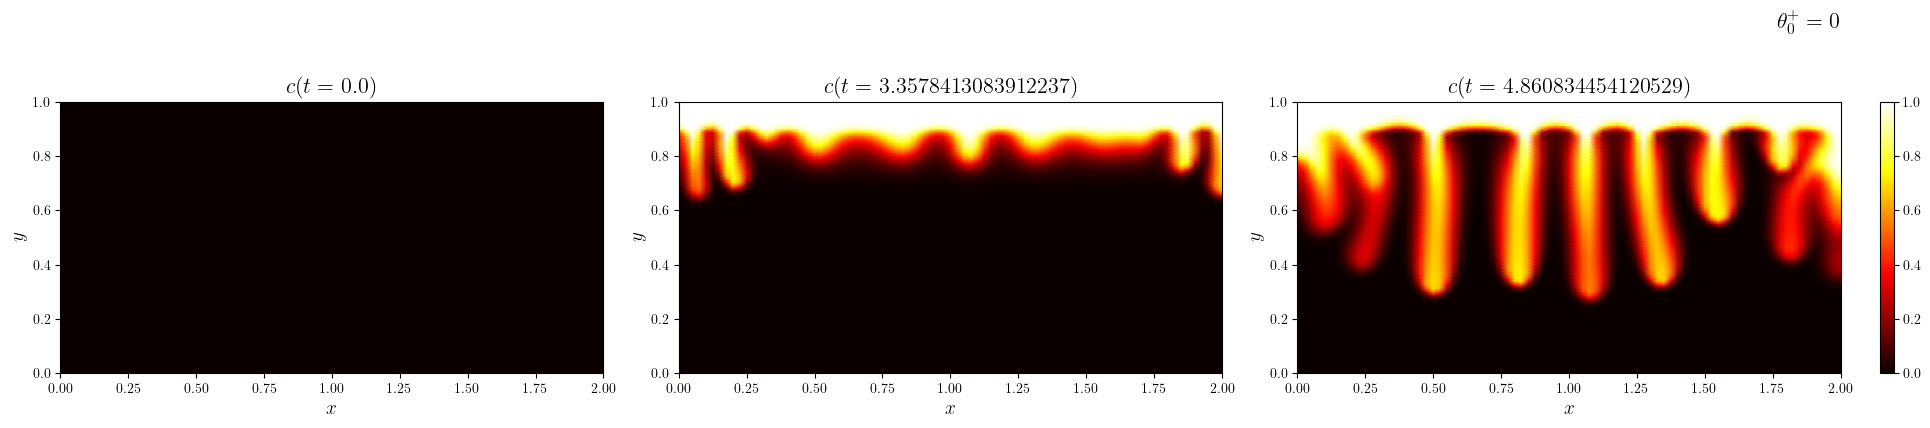

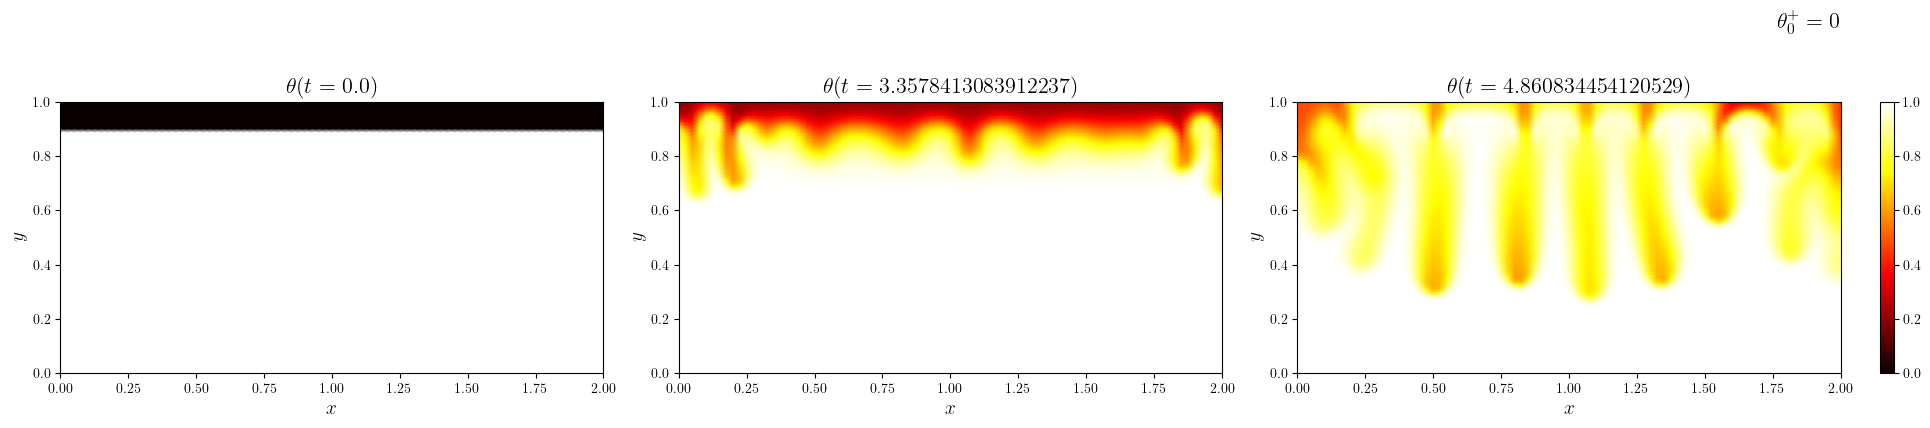

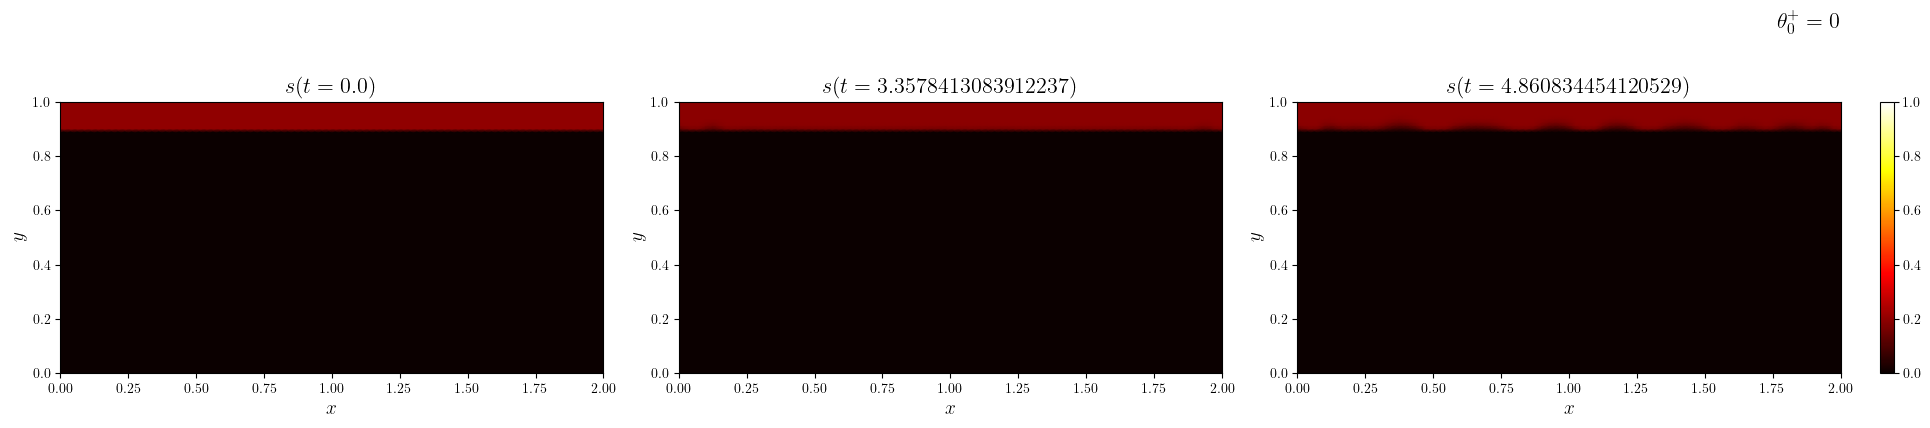

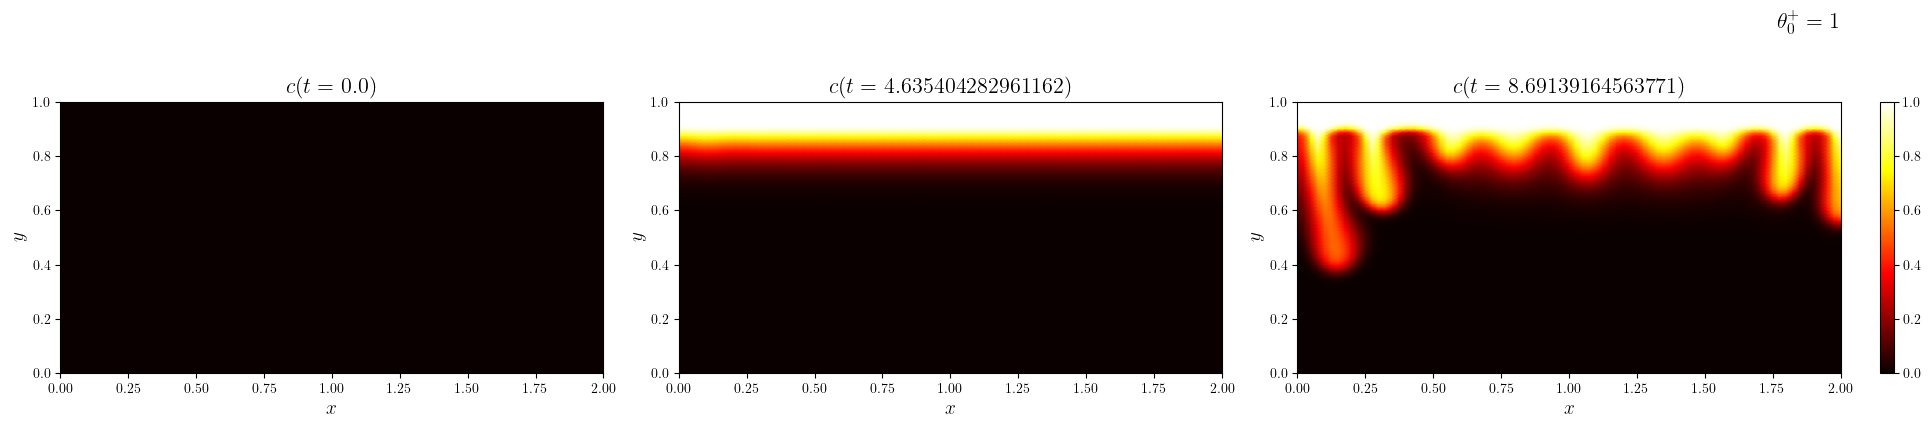

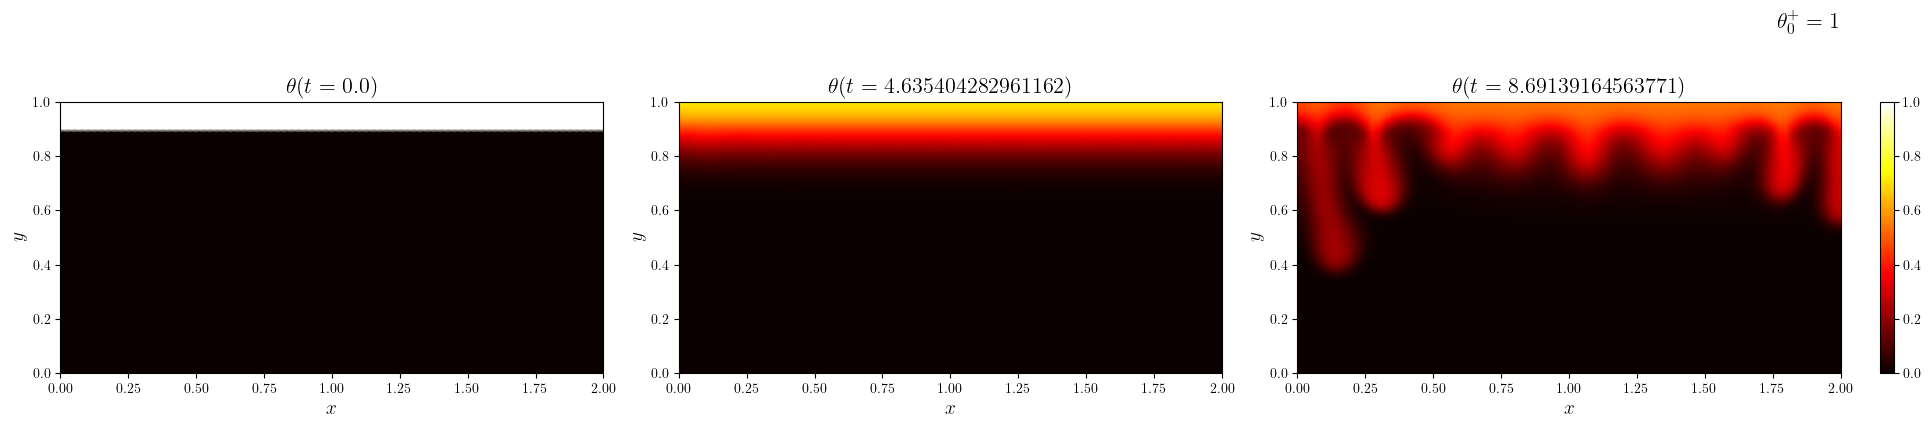

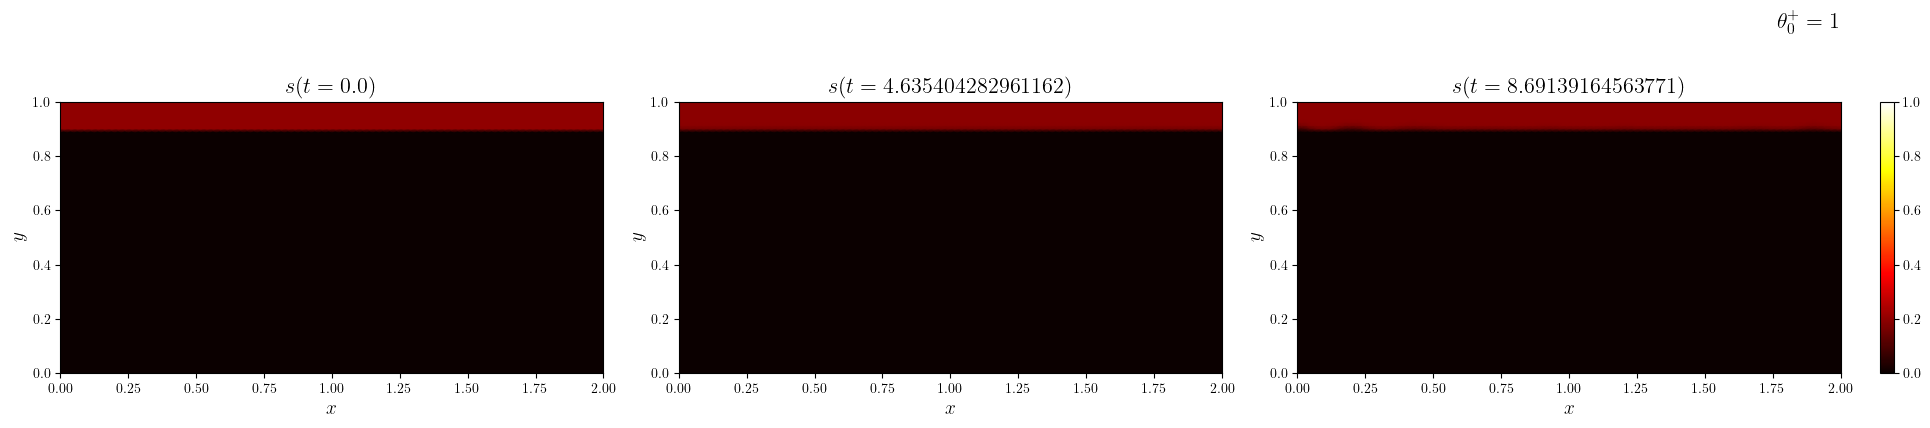

In [4]:
index_targets = (0, 0.5, -1)
tex_names = ('c', '\\theta', 's')

for theta_buoy, sim in simulations.items():
    c, theta, s = sim['c', 'theta', 's']
    time_indices = as_index(c.time_series, index_targets, fraction=True)
    for w, n in zip((c, theta, s), tex_names):
        mfig, axs, _ = plot_colormap_multifigure(
            n_cols=len(time_indices), 
            cbars=(0, 1), 
            suptitle=theta_title(theta_buoy),
        )(
            [w.series[i] for i in time_indices],
            title=[f'${n}(t={w.time_series[i]})$' for i in time_indices],
        )

### Thumbnail image

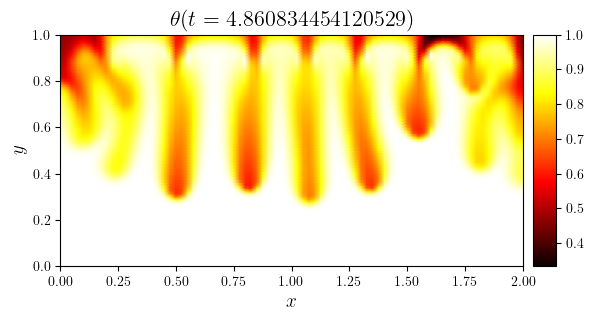

In [6]:
time_index = -1
theta = simulations[True]['theta']
fig, ax = plot_colormap(
    theta.series[time_index], 
    title=f'$\\theta(t={theta.time_series[time_index]})$',
)
save_figure('thumbnail', DIR_ROOT, prefix=False)(fig, file_ext='png')